# IS2SITMOGR4-V4 and IS2SMGPSIT-V1 vs BGEP ULS ice draft

**Summary**: Compares IS2SITMOGR4-V4 and IS2SMGPSIT-V1 monthly sea ice draft with BGEP ULS mooring observations (A, B, D) in the Beaufort Sea, following the chapter 10 approach. Includes monthly anomaly analysis with the calendar-month seasonal cycle removed (cf. daily anomalies in notebook 11c).

**Author**: Alek Petty  
**Version history**: Version 1 (08/2026)


# Import notebook dependencies

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import pyproj
from scipy import stats

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib as mpl

from utils.read_data_utils import read_IS2SITMOGR4, read_is2smgpsitv1_zarr

%config InlineBackend.figure_format = 'retina'
mpl.rcParams['figure.dpi'] = 300

import warnings
warnings.filterwarnings('ignore')

In [2]:
mpl.rcParams.update({
    'text.usetex': False,
    'font.family': 'sans-serif',
    'mathtext.fontset': 'stixsans',
    'lines.linewidth': 1.,
    'font.size': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
})
mpl.rcParams['font.sans-serif'] = ['Arial']

## Load IS2SITMOGR4-V4 and IS2SMGPSIT-V1 products

In [3]:
int_str = '_int'

# IS2SITMOGR4-V4 monthly product (ICESat-2 only), shift timestamps to 15th of month
IS2_v4 = read_IS2SITMOGR4(data_type='zarr-s3-v4', persist=False)

_v4_time = pd.to_datetime(IS2_v4['time'].values)
_v4_start = _v4_time.to_period('M').to_timestamp(how='start')
_v4_mid = _v4_start + pd.Timedelta(days=14)
IS2_v4 = IS2_v4.assign_coords(time=_v4_mid.values)

print('IS2SITMOGR4-V4 loaded')

# Daily fused ICESat-2–SMOS–SMAP product -> monthly means
IS2_SMOS_SMAP = read_is2smgpsitv1_zarr(persist=False, load_cache=True)

IS2_SMOS_SMAP_monthly = IS2_SMOS_SMAP.sortby('time').resample(time='1ME').mean()
_fused_time = pd.to_datetime(IS2_SMOS_SMAP_monthly['time'].values)
_fused_start = _fused_time.to_period('M').to_timestamp(how='start')
_fused_mid = _fused_start + pd.Timedelta(days=14)
IS2_SMOS_SMAP_monthly = IS2_SMOS_SMAP_monthly.assign_coords(time=_fused_mid.values)

if 'latitude' in IS2_SMOS_SMAP.coords:
    IS2_SMOS_SMAP_monthly = IS2_SMOS_SMAP_monthly.assign_coords(latitude=IS2_SMOS_SMAP['latitude'])
if 'longitude' in IS2_SMOS_SMAP.coords:
    IS2_SMOS_SMAP_monthly = IS2_SMOS_SMAP_monthly.assign_coords(longitude=IS2_SMOS_SMAP['longitude'])

print('IS2SMGPSIT-V1 loaded')

load zarr from S3 bucket
zarr_path: s3://icesat-2-sea-ice-us-west-2/IS2SITMOGR4_V4/zarr/IS2SITMOGR4_V4_201811-202504.zarr
IS2SITMOGR4-V4 loaded
Loading IS2-SMOS-SMAP (is2smsitgp) Zarr from local cache
cache_path: ./data/cache/GPSat_multivar_20181101-20250430.zarr
IS2SMGPSIT-V1 loaded


## Map projection and grid setup

IS2SMGPSIT-V1 monthly is on the same EPSG:3411 grid as IS2SITMOGR4-V4, so one **x–y** meshgrid (from V4) is used for distance weighting at both products’ mooring collocations.

In [4]:
out_proj = 'EPSG:3411'
mapProj = pyproj.Proj('+init=' + out_proj)

# Single grid (same projection / cell geometry as fused monthly)
xpts_v4, ypts_v4 = np.meshgrid(IS2_v4.x.values, IS2_v4.y.values)

In [5]:
xpts_v4

array([[-3837500., -3812500., -3787500., ...,  3687500.,  3712500.,
         3737500.],
       [-3837500., -3812500., -3787500., ...,  3687500.,  3712500.,
         3737500.],
       [-3837500., -3812500., -3787500., ...,  3687500.,  3712500.,
         3737500.],
       ...,
       [-3837500., -3812500., -3787500., ...,  3687500.,  3712500.,
         3737500.],
       [-3837500., -3812500., -3787500., ...,  3687500.,  3712500.,
         3737500.],
       [-3837500., -3812500., -3787500., ...,  3687500.,  3712500.,
         3737500.]], dtype=float32)

## Compute ice draft from IS2 thickness for direct comparison with ULS

Ice draft = thickness - freeboard + snow_depth, following the chapter 10 approach.

In [6]:
# IS2SITMOGR4-V4 ice draft
IS2_v4['ice_draft_v4'] = (
    IS2_v4['ice_thickness' + int_str]
    - IS2_v4['freeboard' + int_str]
    + IS2_v4['snow_depth' + int_str]
)

# IS2SMGPSIT-V1 ice draft
IS2_SMOS_SMAP_monthly['ice_draft_fused'] = (
    IS2_SMOS_SMAP_monthly['ice_thickness']
    - IS2_SMOS_SMAP_monthly['freeboard']
    + IS2_SMOS_SMAP_monthly['snow_depth']
)

print('Ice draft variables computed for IS2SITMOGR4-V4 and IS2SMGPSIT-V1')

Ice draft variables computed for IS2SITMOGR4-V4 and IS2SMGPSIT-V1


## Set date range and comparison resolution

In [7]:
start_date = 'Nov 2018'
end_date = 'Apr 2025'

IS2_date_range = pd.date_range(start=start_date, end=end_date, freq='MS') + pd.Timedelta(days=14)
# Filter out summer months (May-Aug) -- winter only, as in chapter 10
IS2_date_range = IS2_date_range[((IS2_date_range.month < 5) | (IS2_date_range.month > 8))]
IS2_date_range_strs = [str(d.year) + '-%02d' % (d.month) for d in IS2_date_range]

comp_res = 100000

print(f'{len(IS2_date_range)} months in range')
print(f'Comparison radius: {comp_res/1000:.0f} km')

54 months in range
Comparison radius: 100 km


## Wrangle BGEP ULS draft data (moorings A, B, D)

Raw files `uls{YY}{a|b|d}_draft.dat` (two-digit deployment **YY** = 18, 21, 22, **23**; mooring letter) should be placed in `./data/`, matching the [BGEP mooring releases](https://www2.whoi.edu/site/beaufortgyre/data/mooring-data/).


In [8]:
dataPathULS = './data/'

def get_ULS_dates(uls_mean_monthly_draft, uls_dates, date):
    a = uls_mean_monthly_draft[uls_dates == date].values[0]
    return a

def get_uls_year(letter, year):
    if letter == 'a':
        print('Mooring A (75.0 N, 150 W)')
        uls_x, uls_y = mapProj(-150., 75.)
    if letter == 'b':
        print('Mooring B (78.4 N, 150.0 W)')
        uls_x, uls_y = mapProj(-150., 78.4)
    if letter == 'd':
        print('Mooring D (74.0 N, 140.0 W)')
        uls_x, uls_y = mapProj(-140., 74.)

    uls = pd.read_csv(
        dataPathULS + 'uls' + year + letter + '_draft.dat',
        sep='\s+', names=['date', 'time', 'draft'], header=2,
    )
    utc_datetime_uls = pd.to_datetime(uls['date'], format='%Y%m%d')

    uls_mean_daily_draft = uls['draft'].groupby([utc_datetime_uls.dt.date]).mean()
    uls_mean_monthly_draft = uls['draft'].groupby([utc_datetime_uls.dt.to_period('M')]).mean()

    return uls_mean_daily_draft, uls_mean_monthly_draft, uls_x, uls_y

In [9]:
uls_mean_daily_draft_a_18, uls_mean_monthly_draft_a_18, uls_x_a, uls_y_a = get_uls_year('a', '18')
uls_mean_daily_draft_b_18, uls_mean_monthly_draft_b_18, uls_x_b, uls_y_b = get_uls_year('b', '18')
uls_mean_daily_draft_d_18, uls_mean_monthly_draft_d_18, uls_x_d, uls_y_d = get_uls_year('d', '18')

Mooring A (75.0 N, 150 W)
Mooring B (78.4 N, 150.0 W)
Mooring D (74.0 N, 140.0 W)


In [10]:
uls_mean_daily_draft_a_21, uls_mean_monthly_draft_a_21, _, _ = get_uls_year('a', '21')
uls_mean_daily_draft_b_21, uls_mean_monthly_draft_b_21, _, _ = get_uls_year('b', '21')
uls_mean_daily_draft_d_21, uls_mean_monthly_draft_d_21, _, _ = get_uls_year('d', '21')

Mooring A (75.0 N, 150 W)
Mooring B (78.4 N, 150.0 W)
Mooring D (74.0 N, 140.0 W)


In [11]:
uls_mean_daily_draft_a_22, uls_mean_monthly_draft_a_22, _, _ = get_uls_year('a', '22')
uls_mean_daily_draft_b_22, uls_mean_monthly_draft_b_22, _, _ = get_uls_year('b', '22')
uls_mean_daily_draft_d_22, uls_mean_monthly_draft_d_22, _, _ = get_uls_year('d', '22')

Mooring A (75.0 N, 150 W)
Mooring B (78.4 N, 150.0 W)
Mooring D (74.0 N, 140.0 W)


In [12]:
uls_mean_daily_draft_a_23, uls_mean_monthly_draft_a_23, _, _ = get_uls_year('a', '23')
uls_mean_daily_draft_b_23, uls_mean_monthly_draft_b_23, _, _ = get_uls_year('b', '23')
uls_mean_daily_draft_d_23, uls_mean_monthly_draft_d_23, _, _ = get_uls_year('d', '23')


Mooring A (75.0 N, 150 W)
Mooring B (78.4 N, 150.0 W)
Mooring D (74.0 N, 140.0 W)


In [13]:
uls_mean_daily_draft_a = pd.concat([uls_mean_daily_draft_a_18, uls_mean_daily_draft_a_21, uls_mean_daily_draft_a_22, uls_mean_daily_draft_a_23])
uls_mean_daily_draft_b = pd.concat([uls_mean_daily_draft_b_18, uls_mean_daily_draft_b_21, uls_mean_daily_draft_b_22, uls_mean_daily_draft_b_23])
uls_mean_daily_draft_d = pd.concat([uls_mean_daily_draft_d_18, uls_mean_daily_draft_d_21, uls_mean_daily_draft_d_22, uls_mean_daily_draft_d_23])

uls_mean_monthly_draft_a = pd.concat([uls_mean_monthly_draft_a_18, uls_mean_monthly_draft_a_21, uls_mean_monthly_draft_a_22, uls_mean_monthly_draft_a_23])
uls_mean_monthly_draft_b = pd.concat([uls_mean_monthly_draft_b_18, uls_mean_monthly_draft_b_21, uls_mean_monthly_draft_b_22, uls_mean_monthly_draft_b_23])
uls_mean_monthly_draft_d = pd.concat([uls_mean_monthly_draft_d_18, uls_mean_monthly_draft_d_21, uls_mean_monthly_draft_d_22, uls_mean_monthly_draft_d_23])

## Subset IS2 to Beaufort and winter months

Load both products restricted to a Beaufort bounding box and Nov–Apr months for faster collocation.

## Collocate IS2SITMOGR4-V4 and IS2SMGPSIT-V1 ice draft at BGEP mooring locations

Following chapter 10, we average all IS2 grid cells within a given radius (`comp_res`) of each mooring location.

In [14]:
def grid_IS2_nearby(ds, var_name, date, uls_x, uls_y, xpts, ypts, res=100000):
    """Average IS2 grid cells within `res` metres of the mooring."""
    try:
        IS2 = ds[var_name].sel(time=date, method='nearest', tolerance=pd.Timedelta(days=20))
    except KeyError:
        return np.nan
    dist = np.sqrt((xpts - uls_x)**2 + (ypts - uls_y)**2)
    IS2_uls = IS2.where(dist < res).mean()
    return float(IS2_uls.values)

In [15]:
options = {
    'IS2SITMOGR4-V4': {'ds': IS2_v4, 'var': 'ice_draft_v4', 'xpts': xpts_v4, 'ypts': ypts_v4},
    'IS2SMGPSIT-V1': {'ds': IS2_SMOS_SMAP_monthly, 'var': 'ice_draft_fused', 'xpts': xpts_v4, 'ypts': ypts_v4},
}

mooring_info = {
    'a': {'x': uls_x_a, 'y': uls_y_a},
    'b': {'x': uls_x_b, 'y': uls_y_b},
    'd': {'x': uls_x_d, 'y': uls_y_d},
}

monthly_IS2_at_ULS = {}

for option, opt_info in options.items():
    monthly_IS2_at_ULS[option] = {}
    for letter, m_info in mooring_info.items():
        monthly_IS2_at_ULS[option][letter] = [
            grid_IS2_nearby(opt_info['ds'], opt_info['var'], date,
                            m_info['x'], m_info['y'],
                            opt_info['xpts'], opt_info['ypts'], res=comp_res)
            for date in IS2_date_range
        ]
    monthly_IS2_at_ULS[option]['all'] = (
        monthly_IS2_at_ULS[option]['a']
        + monthly_IS2_at_ULS[option]['b']
        + monthly_IS2_at_ULS[option]['d']
    )

print('Collocation complete')

Collocation complete


## Extract BGEP monthly drafts for the IS2 date range

In [16]:
uls_dates_a = uls_mean_monthly_draft_a.index.astype(str)
uls_dates_b = uls_mean_monthly_draft_b.index.astype(str)
uls_dates_d = uls_mean_monthly_draft_d.index.astype(str)

uls_mean_monthly_draft_a_IS2_period = [
    get_ULS_dates(uls_mean_monthly_draft_a, uls_dates_a, d)
    for d in IS2_date_range_strs if d in uls_dates_a.values
]
uls_mean_monthly_draft_b_IS2_period = [
    get_ULS_dates(uls_mean_monthly_draft_b, uls_dates_b, d)
    for d in IS2_date_range_strs if d in uls_dates_b.values
]
uls_mean_monthly_draft_d_IS2_period = [
    get_ULS_dates(uls_mean_monthly_draft_d, uls_dates_d, d)
    for d in IS2_date_range_strs if d in uls_dates_d.values
]

# Keep only dates that have ULS data
IS2_dates_with_uls_a = [d for d, s in zip(IS2_date_range, IS2_date_range_strs) if s in uls_dates_a.values]
IS2_dates_with_uls_b = [d for d, s in zip(IS2_date_range, IS2_date_range_strs) if s in uls_dates_b.values]
IS2_dates_with_uls_d = [d for d, s in zip(IS2_date_range, IS2_date_range_strs) if s in uls_dates_d.values]

# Filter IS2 collocated values to only ULS-available dates
monthly_IS2_at_ULS_filtered = {}
for option in options.keys():
    monthly_IS2_at_ULS_filtered[option] = {}
    for letter, dates_with_uls in [('a', IS2_dates_with_uls_a),
                                    ('b', IS2_dates_with_uls_b),
                                    ('d', IS2_dates_with_uls_d)]:
        idx = [i for i, d in enumerate(IS2_date_range) if d in dates_with_uls]
        monthly_IS2_at_ULS_filtered[option][letter] = [
            monthly_IS2_at_ULS[option][letter][i] for i in idx
        ]
    monthly_IS2_at_ULS_filtered[option]['all'] = (
        monthly_IS2_at_ULS_filtered[option]['a']
        + monthly_IS2_at_ULS_filtered[option]['b']
        + monthly_IS2_at_ULS_filtered[option]['d']
    )

uls_mean_monthly_draft_IS2_period = (
    uls_mean_monthly_draft_a_IS2_period
    + uls_mean_monthly_draft_b_IS2_period
    + uls_mean_monthly_draft_d_IS2_period
)

print(f'ULS months available: A={len(uls_mean_monthly_draft_a_IS2_period)}, '
      f'B={len(uls_mean_monthly_draft_b_IS2_period)}, '
      f'D={len(uls_mean_monthly_draft_d_IS2_period)}')

ULS months available: A=47, B=47, D=47


## Validation analysis: r², mean bias, standard deviation, RMSE

In [17]:
validation_results = {}

for option in options.keys():
    vr = {}
    for letter, uls_period in [('a', uls_mean_monthly_draft_a_IS2_period),
                                ('b', uls_mean_monthly_draft_b_IS2_period),
                                ('d', uls_mean_monthly_draft_d_IS2_period),
                                ('all', uls_mean_monthly_draft_IS2_period)]:
        is2_vals = np.array(monthly_IS2_at_ULS_filtered[option][letter])
        uls_vals = np.array(uls_period)
        mask = ~np.isnan(is2_vals) & ~np.isnan(uls_vals)

        if mask.sum() >= 2:
            res = stats.linregress(is2_vals[mask], uls_vals[mask])
            r2 = res[2]**2
            mb = np.nanmean(is2_vals - uls_vals)
            sd = np.nanstd(is2_vals - uls_vals)
            rmse = np.sqrt(np.nanmean((is2_vals - uls_vals)**2))
        else:
            r2 = mb = sd = rmse = np.nan

        vr[f'r2_{letter}'] = r2
        vr[f'mb_{letter}'] = mb
        vr[f'sd_{letter}'] = sd
        vr[f'rmse_{letter}'] = rmse
        vr[f'n_{letter}'] = int(mask.sum())

    validation_results[option] = vr

for option, vr in validation_results.items():
    print(f'\n{option}:')
    for letter in ['a', 'b', 'd', 'all']:
        print(f"  {letter.upper():>3s}: N={vr[f'n_{letter}']:3d}  r\u00b2={vr[f'r2_{letter}']:.2f}  "
              f"MB={vr[f'mb_{letter}']:.2f} m  "
              f"SD={vr[f'sd_{letter}']:.2f} m  "
              f"RMSE={vr[f'rmse_{letter}']:.2f} m")

_v4 = validation_results['IS2SITMOGR4-V4']
_fu = validation_results['IS2SMGPSIT-V1']
print("\n--- Manuscript summary (monthly ice draft; satellite = thickness $-$ freeboard $+$ snow; 100~km collocation) ---")
print(
    f"Pooled A+B+D:  IS2SMGPSIT-V1  r^2={_fu['r2_all']:.2f}, mean bias={_fu['mb_all']:.2f}~m, RMSE={_fu['rmse_all']:.2f}~m, N={_fu['n_all']}\n"
    f"                IS2SITMOGR4-V4 r^2={_v4['r2_all']:.2f}, mean bias={_v4['mb_all']:.2f}~m, RMSE={_v4['rmse_all']:.2f}~m, N={_v4['n_all']}"
)
print(
    f"Mooring A:     fused r^2={_fu['r2_a']:.2f}, MB={_fu['mb_a']:.2f}~m  |  "
    f"V4 r^2={_v4['r2_a']:.2f}, MB={_v4['mb_a']:.2f}~m"
)



IS2SITMOGR4-V4:
    A: N= 41  r²=0.87  MB=0.14 m  SD=0.19 m  RMSE=0.23 m
    B: N= 46  r²=0.85  MB=-0.03 m  SD=0.22 m  RMSE=0.23 m
    D: N= 43  r²=0.88  MB=0.19 m  SD=0.19 m  RMSE=0.27 m
  ALL: N=130  r²=0.83  MB=0.10 m  SD=0.22 m  RMSE=0.24 m

IS2SMGPSIT-V1:
    A: N= 46  r²=0.94  MB=0.04 m  SD=0.16 m  RMSE=0.17 m
    B: N= 47  r²=0.92  MB=-0.09 m  SD=0.17 m  RMSE=0.19 m
    D: N= 47  r²=0.92  MB=0.08 m  SD=0.19 m  RMSE=0.21 m
  ALL: N=140  r²=0.91  MB=0.01 m  SD=0.19 m  RMSE=0.19 m

--- Manuscript summary (monthly ice draft; satellite = thickness $-$ freeboard $+$ snow; 100~km collocation) ---
Pooled A+B+D:  IS2SMGPSIT-V1  r^2=0.91, mean bias=0.01~m, RMSE=0.19~m, N=140
                IS2SITMOGR4-V4 r^2=0.83, mean bias=0.10~m, RMSE=0.24~m, N=130
Mooring A:     fused r^2=0.94, MB=0.04~m  |  V4 r^2=0.87, MB=0.14~m


## Time series: BGEP draft vs IS2 ice draft at moorings A, B, D

Daily ULS draft shown as grey background, monthly ULS as dashed black line, IS2SITMOGR4-V4 and IS2SMGPSIT-V1 ice draft as scatter markers.

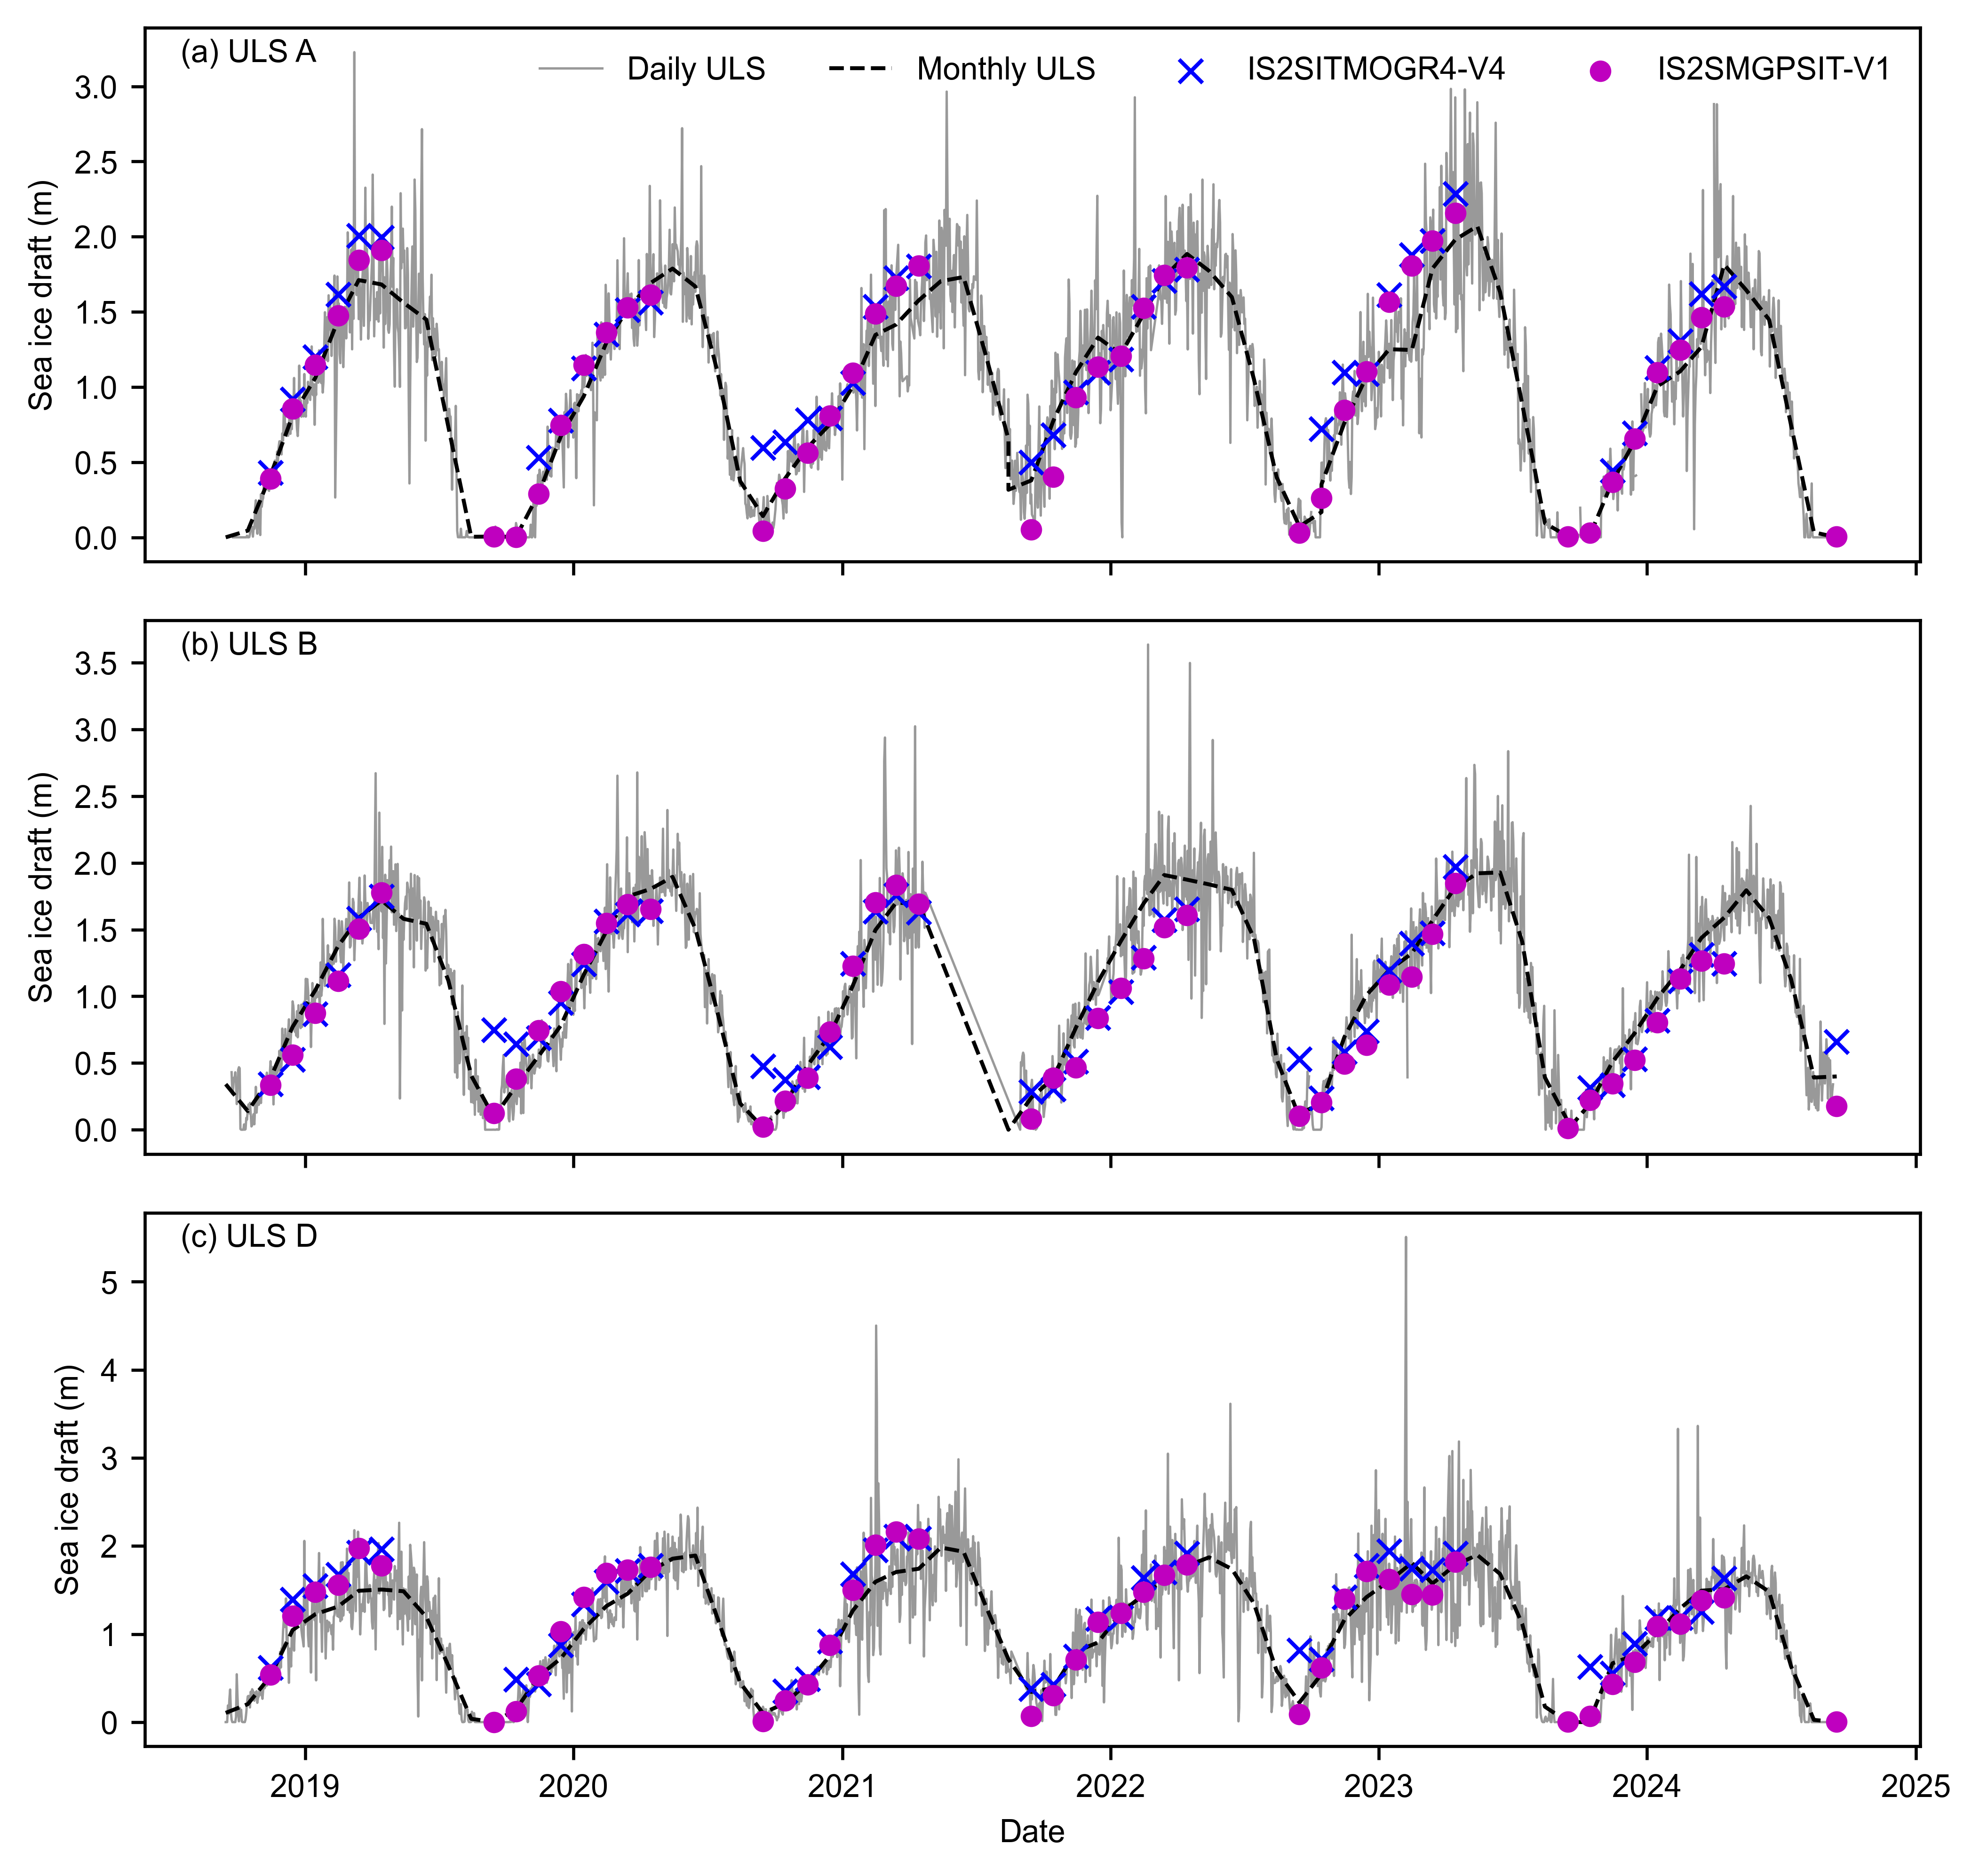

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(6.8, 7), sharex=True)

daily_data = {
    'a': uls_mean_daily_draft_a,
    'b': uls_mean_daily_draft_b,
    'd': uls_mean_daily_draft_d,
}
monthly_data = {
    'a': uls_mean_monthly_draft_a,
    'b': uls_mean_monthly_draft_b,
    'd': uls_mean_monthly_draft_d,
}
dates_with_uls = {
    'a': IS2_dates_with_uls_a,
    'b': IS2_dates_with_uls_b,
    'd': IS2_dates_with_uls_d,
}
panel_labels = ['(a) ULS A', '(b) ULS B', '(c) ULS D']
letters_plot = ['a', 'b', 'd']

for ax, letter, panel_label in zip(axes, letters_plot, panel_labels):
    # Daily ULS
    ax.plot(daily_data[letter].index, daily_data[letter],
            label='Daily ULS', color='gray', linewidth=0.6, alpha=0.8)
    # Monthly ULS
    ax.plot(monthly_data[letter].index.to_timestamp() + pd.Timedelta(days=14),
            monthly_data[letter],
            label='Monthly ULS', linestyle='--', color='k')
    # IS2SITMOGR4-V4
    ax.scatter(dates_with_uls[letter],
               monthly_IS2_at_ULS_filtered['IS2SITMOGR4-V4'][letter],
               label='IS2SITMOGR4-V4', color='b', marker='x', zorder=5)
    # IS2SMGPSIT-V1
    ax.scatter(dates_with_uls[letter],
               monthly_IS2_at_ULS_filtered['IS2SMGPSIT-V1'][letter],
               label='IS2SMGPSIT-V1', color='m', marker='o', s=20, zorder=5)

    ax.annotate(panel_label, xy=(0.02, 0.98), xycoords='axes fraction',
                verticalalignment='top')
    ax.set_ylabel('Sea ice draft (m)')

axes[0].legend(loc='upper right', frameon=False, ncol=4)
axes[2].set_xlabel('Date')

plt.subplots_adjust(left=0.065, right=0.99, top=0.95, bottom=0.08, hspace=0.11)
plt.savefig('../paper/figures/BGEP_V4_vs_V1_timeseries.png', dpi=300)
plt.show()

## Scatter plots: IS2 ice draft vs BGEP draft

One column per product (IS2SITMOGR4-V4, IS2SMGPSIT-V1), coloured by mooring (A=blue, B=red, D=orange), following chapter 10.

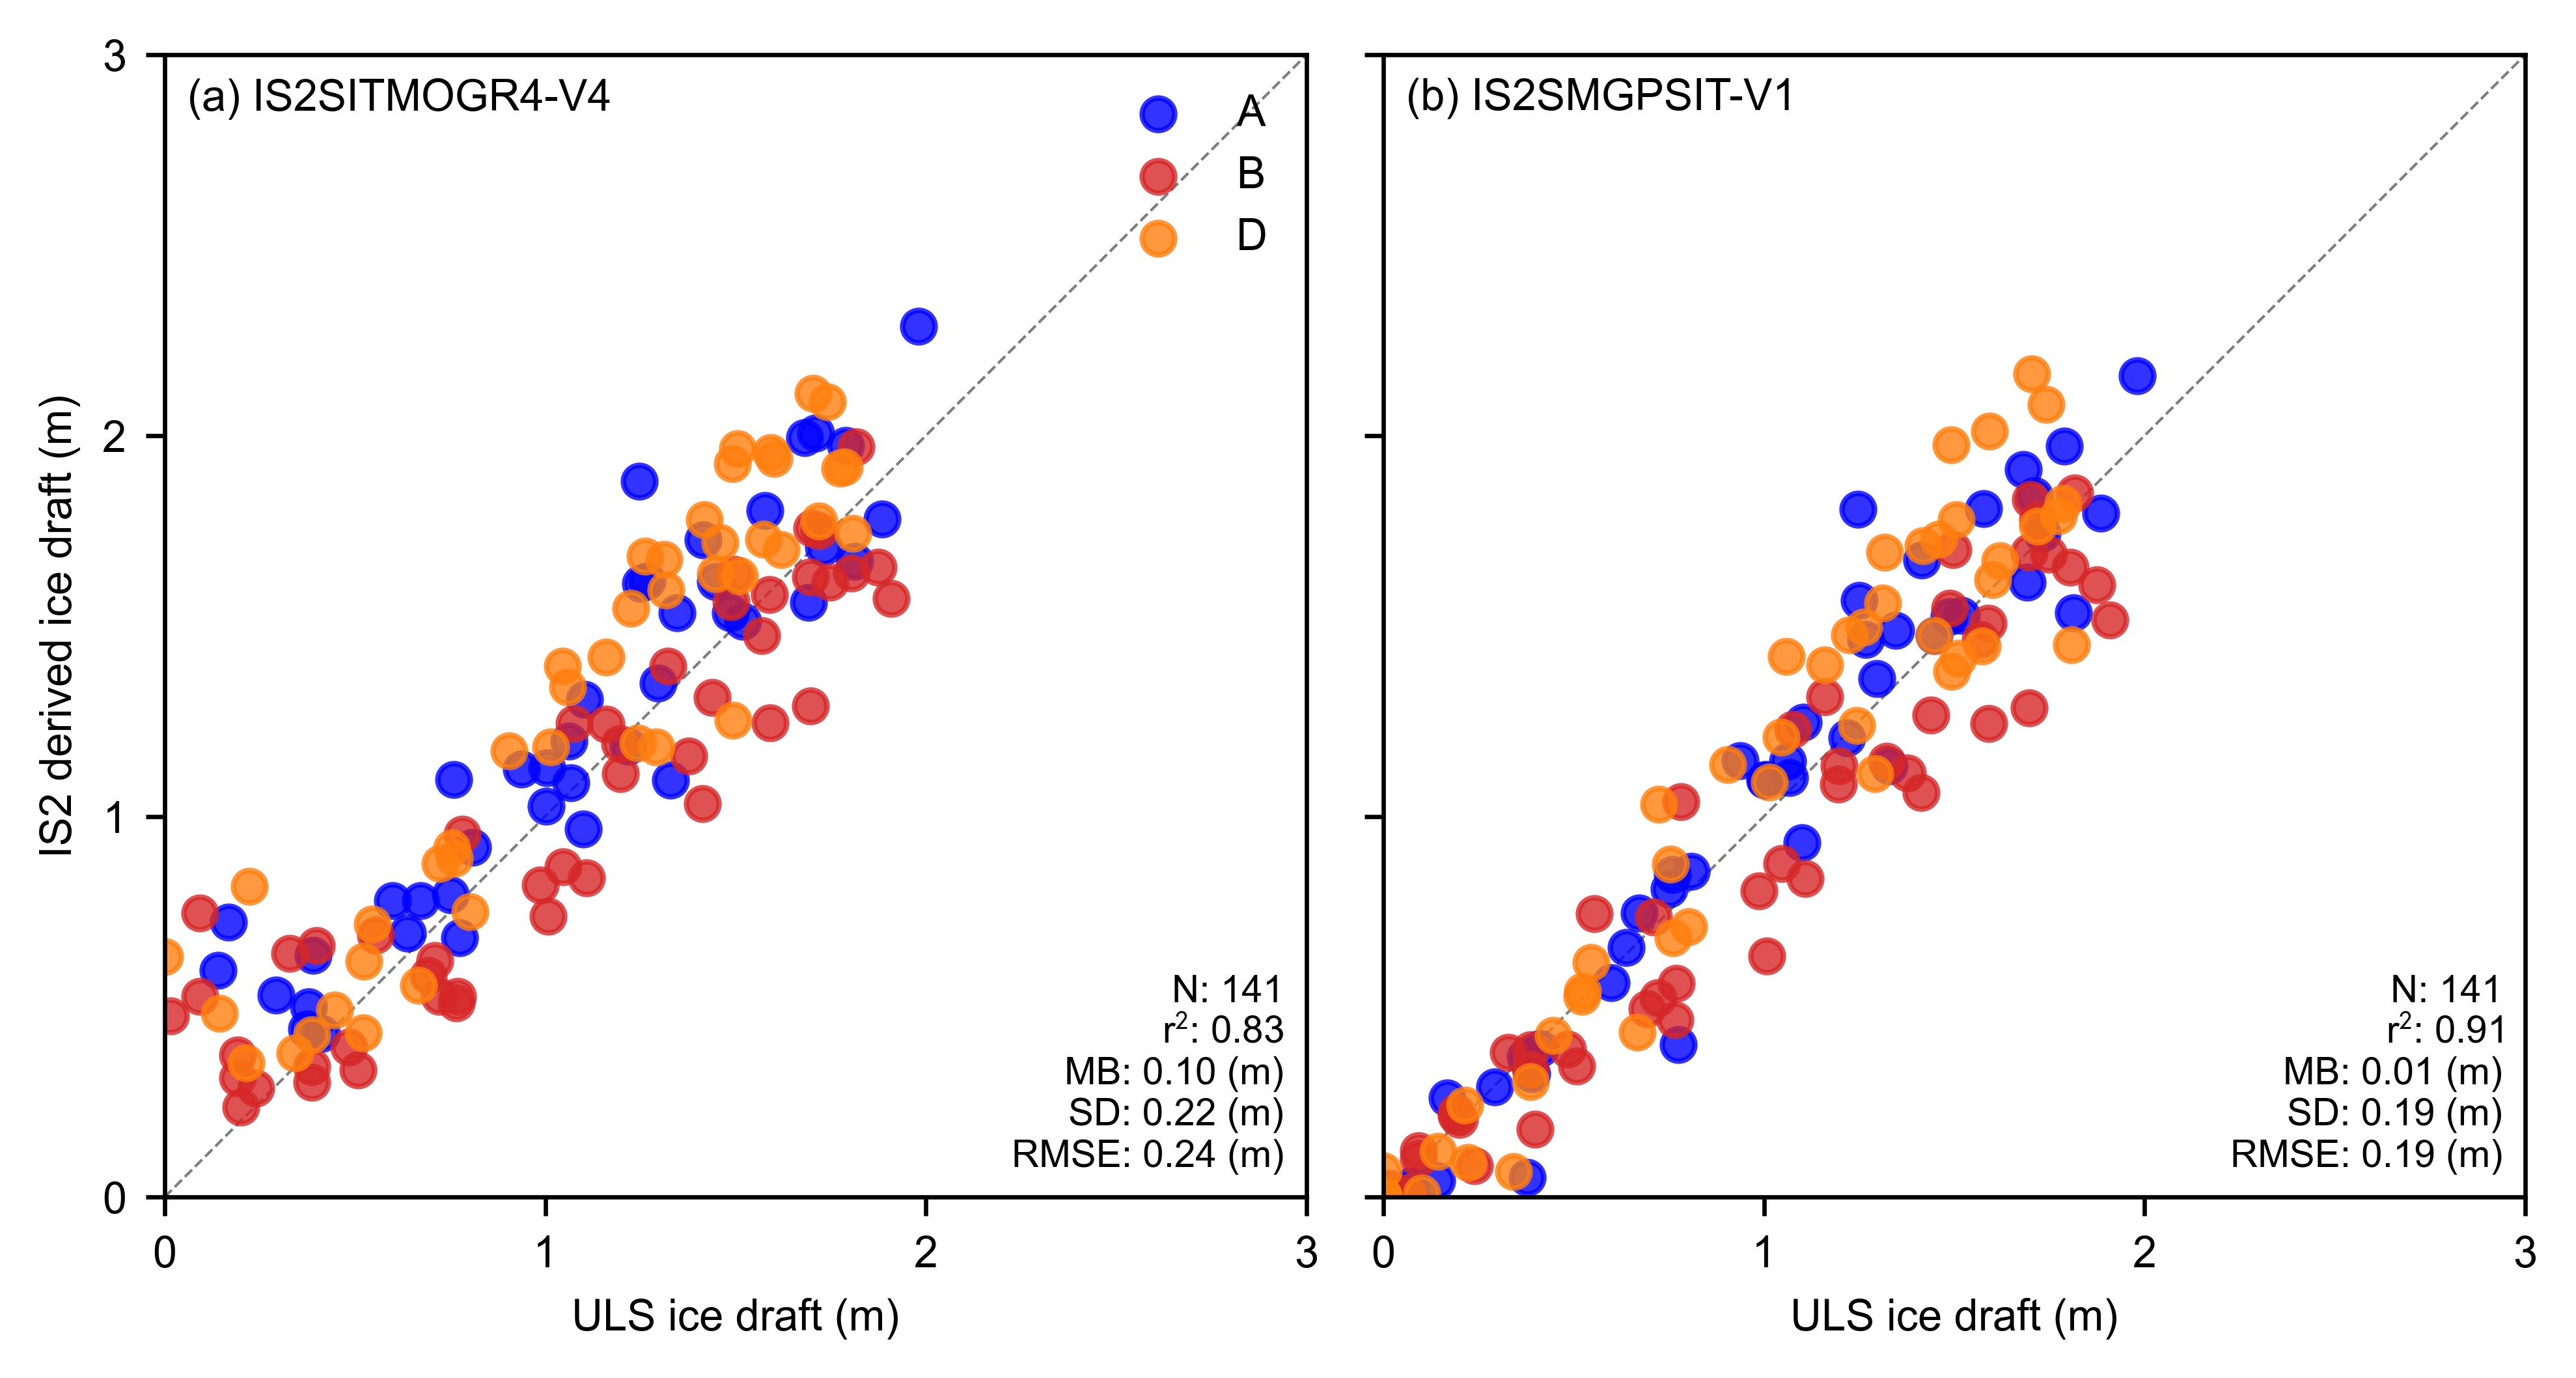

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(6.8, 3.4),
                         gridspec_kw={'wspace': 0.04})

panel_labels = ['(a)', '(b)']

for i, option in enumerate(options.keys()):
    ax = axes[i]
    ax.scatter(uls_mean_monthly_draft_a_IS2_period,
               monthly_IS2_at_ULS_filtered[option]['a'],
               color='b', alpha=0.8, label='A')
    ax.scatter(uls_mean_monthly_draft_b_IS2_period,
               monthly_IS2_at_ULS_filtered[option]['b'],
               color='tab:red', alpha=0.8, label='B')
    ax.scatter(uls_mean_monthly_draft_d_IS2_period,
               monthly_IS2_at_ULS_filtered[option]['d'],
               color='tab:orange', alpha=0.8, label='D')

    vr = validation_results[option]
    n_str = str(len(monthly_IS2_at_ULS_filtered[option]['all']))
    ax.annotate(
        f"N: {n_str}\n"
        f"r$^2$: {vr['r2_all']:.2f}\n"
        f"MB: {vr['mb_all']:.2f} (m)\n"
        f"SD: {vr['sd_all']:.2f} (m)\n"
        f"RMSE: {vr['rmse_all']:.2f} (m)",
        color='k', xy=(0.98, 0.02), xycoords='axes fraction',
        horizontalalignment='right', verticalalignment='bottom', fontsize=7,
    )

    ax.annotate(f'{panel_labels[i]} {option}', xy=(0.02, 0.98),
                xycoords='axes fraction', ha='left', va='top')

    if i == 0:
        ax.legend(frameon=False, loc='upper right')
        ax.set_ylabel('IS2 derived ice draft (m)')
    else:
        ax.set_yticklabels('')

    ax.set_xlabel('ULS ice draft (m)')
    ax.set_xlim([0, 3])
    ax.set_ylim([0, 3])
    ax.set_xticks([0, 1, 2, 3])
    ax.set_yticks([0, 1, 2, 3])

    lims = [0, 4]
    ax.plot(lims, lims, 'k--', linewidth=0.5, alpha=0.5, zorder=0)
    ax.set_aspect('equal')

plt.subplots_adjust(left=0.08, right=0.98, top=0.98, bottom=0.12)
plt.savefig('../paper/figures/BGEP_V4_vs_V1_scatter.png', dpi=300)
plt.show()


## Monthly anomalies (seasonal cycle removed)

Remove the calendar-month climatology (mean draft for each Nov–Apr month, pooled across years) to compare interannual variability without the within-season growth signal. This is the monthly counterpart to the day-of-year anomaly analysis in notebook 11c.

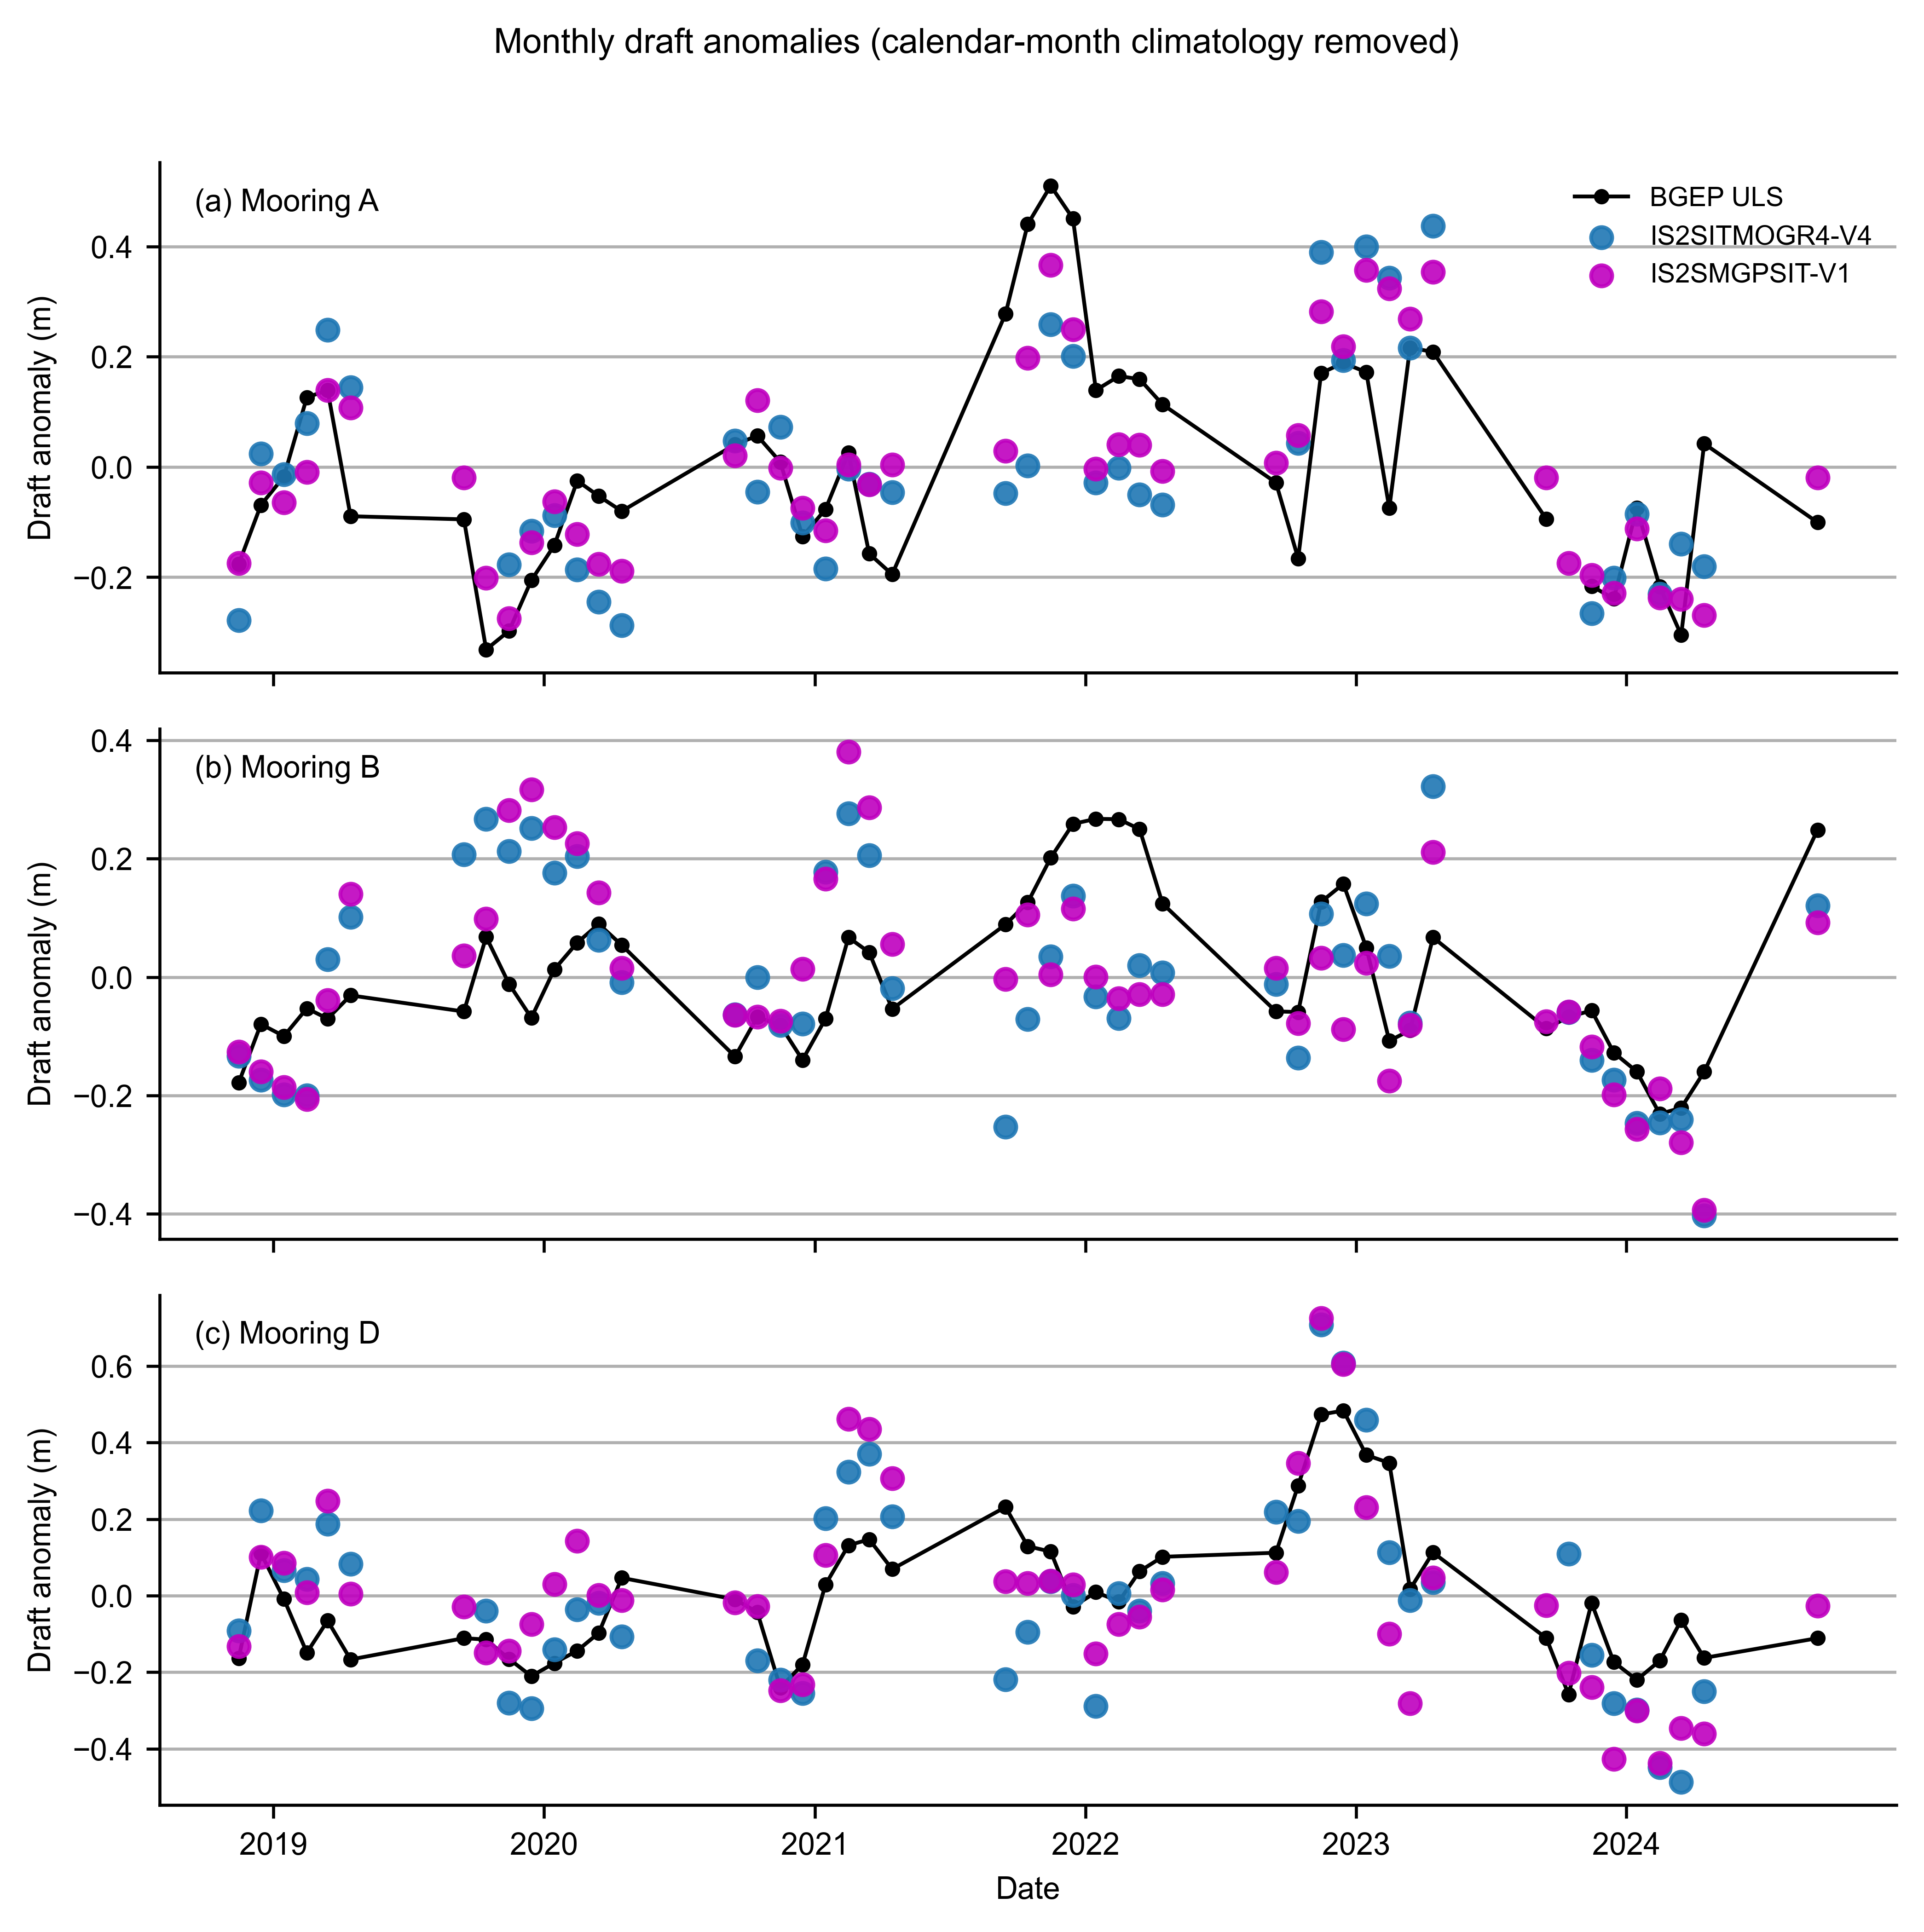

Correlation of BGEP ULS monthly draft anomalies with IS2 products (pooled A+B+D):
  IS2SITMOGR4-V4: r=0.60  (N=130)
  IS2SMGPSIT-V1: r=0.65  (N=140)
Std of monthly draft anomalies (m):
  BGEP ULS: 0.17
  IS2SITMOGR4-V4: 0.21
  IS2SMGPSIT-V1: 0.20


In [20]:
# Build monthly collocated DataFrames (one row per winter month with ULS data)
uls_period = {
    'a': uls_mean_monthly_draft_a_IS2_period,
    'b': uls_mean_monthly_draft_b_IS2_period,
    'd': uls_mean_monthly_draft_d_IS2_period,
}

monthly_colloc = {}
for letter in ['a', 'b', 'd']:
    monthly_colloc[letter] = pd.DataFrame({
        'uls_draft': uls_period[letter],
        'v4_monthly': monthly_IS2_at_ULS_filtered['IS2SITMOGR4-V4'][letter],
        'fused_monthly': monthly_IS2_at_ULS_filtered['IS2SMGPSIT-V1'][letter],
    }, index=pd.to_datetime(dates_with_uls[letter]))

# Subtract calendar-month climatology per mooring
monthly_colloc_anom = {}
for letter in ['a', 'b', 'd']:
    df = monthly_colloc[letter].copy()
    cal_month = df.index.month
    for col in ['uls_draft', 'v4_monthly', 'fused_monthly']:
        clim = df.groupby(cal_month)[col].mean()
        df[col + '_anom'] = df[col].values - clim.reindex(cal_month).values
    monthly_colloc_anom[letter] = df

# Time series of monthly draft anomalies
panel_labels = ['(a) Mooring A', '(b) Mooring B', '(c) Mooring D']
fig, axes = plt.subplots(3, 1, figsize=(6.8, 7), sharex=True)

for ax, letter, panel_label in zip(axes, ['a', 'b', 'd'], panel_labels):
    df = monthly_colloc_anom[letter]
    ax.plot(df.index, df['uls_draft_anom'], color='k', linewidth=1.0,
            marker='o', markersize=3, label='BGEP ULS', zorder=3)
    mask_v4 = df['v4_monthly_anom'].notna()
    ax.scatter(df.index[mask_v4], df['v4_monthly_anom'][mask_v4],
               color='C0', s=30, alpha=0.9, label='IS2SITMOGR4-V4', zorder=5)
    mask_fu = df['fused_monthly_anom'].notna()
    ax.scatter(df.index[mask_fu], df['fused_monthly_anom'][mask_fu],
               color='m', s=30, alpha=0.9, label='IS2SMGPSIT-V1', zorder=5)
    ax.axhline(0, color='0.6', linewidth=0.5, linestyle='--', zorder=0)
    ax.set_ylabel('Draft anomaly (m)')
    ax.grid(axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.text(0.02, 0.95, panel_label, transform=ax.transAxes, fontsize=8, verticalalignment='top')

axes[0].legend(loc='upper right', frameon=False, ncol=1, fontsize=7)
axes[-1].set_xlabel('Date')
fig.suptitle('Monthly draft anomalies (calendar-month climatology removed)', y=1.00, fontsize=9)
plt.subplots_adjust(left=0.065, right=0.99, top=0.93, bottom=0.08, hspace=0.11)
plt.savefig('./figs/BGEP_V4_fused_monthly_timeseries_anomaly.png', dpi=300)
plt.show()

# Correlation of ULS anomalies with each IS2 product (pooled A+B+D)
print('Correlation of BGEP ULS monthly draft anomalies with IS2 products (pooled A+B+D):')
for prod, label in zip(['v4_monthly', 'fused_monthly'],
                       ['IS2SITMOGR4-V4', 'IS2SMGPSIT-V1']):
    uls_anom = np.concatenate([monthly_colloc_anom[l]['uls_draft_anom'].values for l in ['a', 'b', 'd']])
    is2_anom = np.concatenate([monthly_colloc_anom[l][prod + '_anom'].values for l in ['a', 'b', 'd']])
    mask = np.isfinite(uls_anom) & np.isfinite(is2_anom)
    r = np.corrcoef(uls_anom[mask], is2_anom[mask])[0, 1] if mask.sum() >= 2 else np.nan
    print(f'  {label}: r={r:.2f}  (N={mask.sum()})')

print('Std of monthly draft anomalies (m):')
for col, label in [('uls_draft_anom', 'BGEP ULS'),
                   ('v4_monthly_anom', 'IS2SITMOGR4-V4'),
                   ('fused_monthly_anom', 'IS2SMGPSIT-V1')]:
    vals = np.concatenate([monthly_colloc_anom[l][col].values for l in ['a', 'b', 'd']])
    print(f'  {label}: {np.nanstd(vals):.2f}')

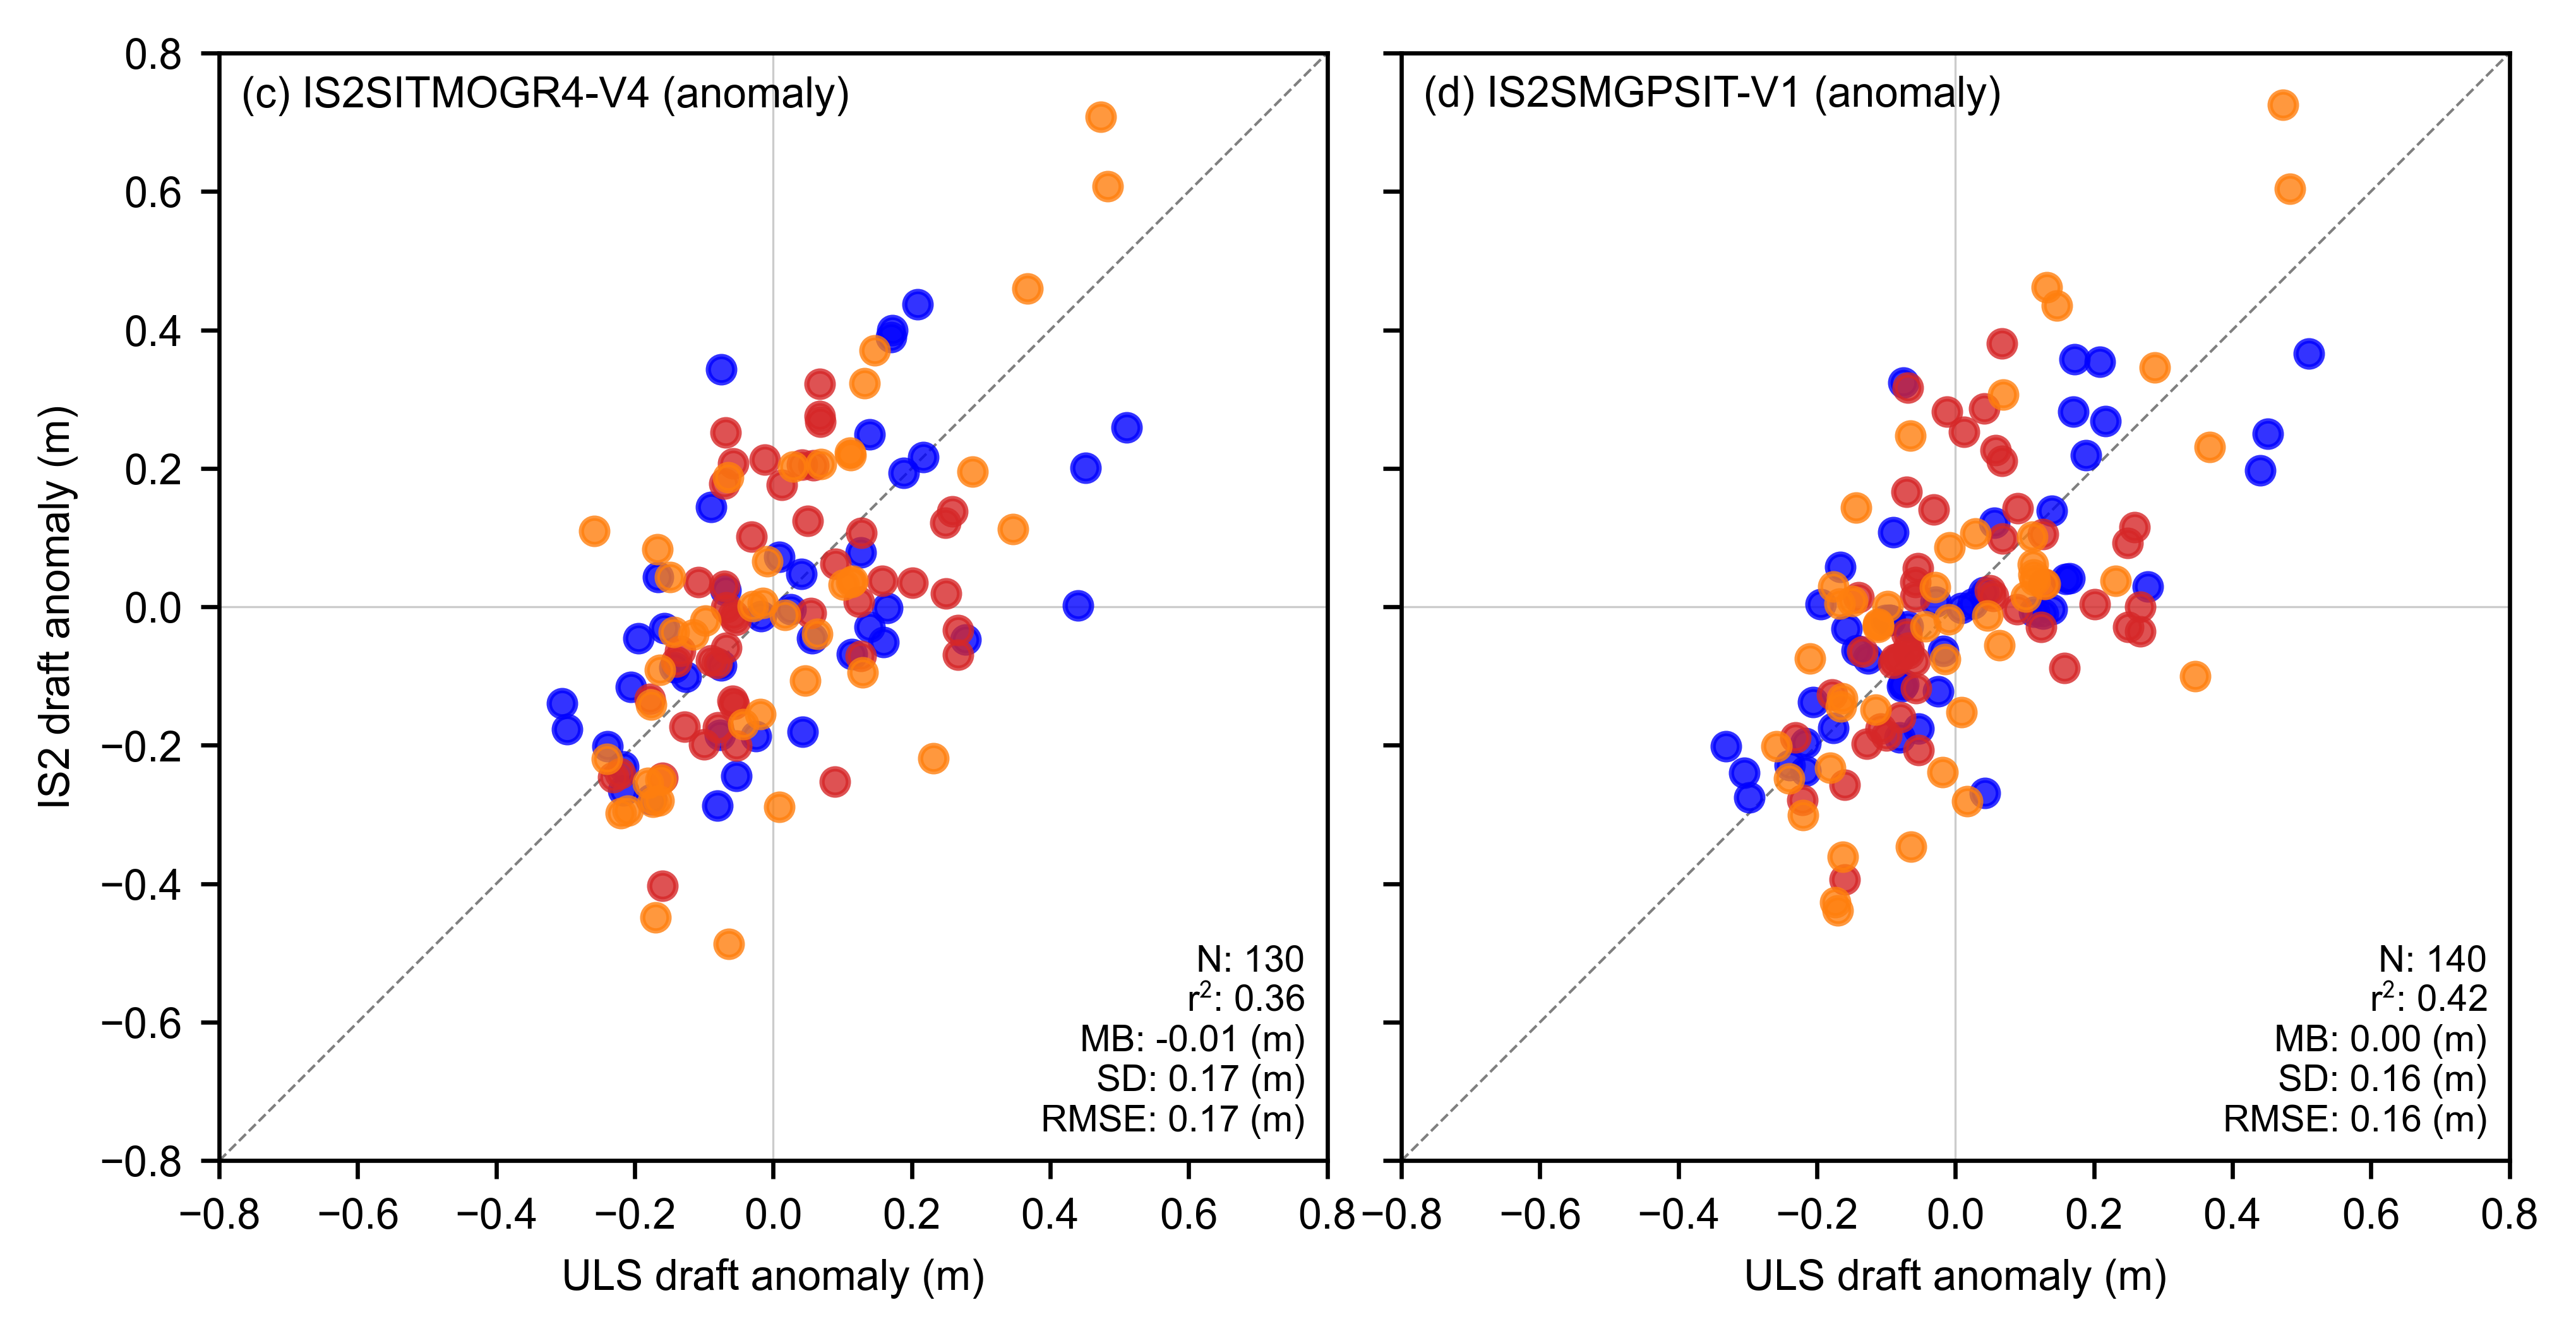

Correlation/fit statistics of monthly draft anomalies (pooled A+B+D):
  IS2SITMOGR4-V4 (anomaly): N=130, r^2=0.36, MB=-0.01 m, SD=0.17 m, RMSE=0.17 m
  IS2SMGPSIT-V1 (anomaly): N=140, r^2=0.42, MB=0.00 m, SD=0.16 m, RMSE=0.16 m


In [21]:
# Scatter plots: monthly draft anomalies
anom_products = ['v4_monthly_anom', 'fused_monthly_anom']
anom_labels = ['IS2SITMOGR4-V4 (anomaly)', 'IS2SMGPSIT-V1 (anomaly)']
mooring_colors = {'a': 'b', 'b': 'tab:red', 'd': 'tab:orange'}

validation_results_anom = {}

for prod, label in zip(anom_products, anom_labels):
    vr = {}
    for letter in ['a', 'b', 'd']:
        df = monthly_colloc_anom[letter]
        mask = np.isfinite(df['uls_draft_anom']) & np.isfinite(df[prod])
        if mask.sum() >= 2:
            res = stats.linregress(df[prod][mask], df['uls_draft_anom'][mask])
            vr[f'r2_{letter}'] = res.rvalue**2
            vr[f'mb_{letter}'] = np.nanmean(df[prod][mask].values - df['uls_draft_anom'][mask].values)
            vr[f'sd_{letter}'] = np.nanstd(df[prod][mask].values - df['uls_draft_anom'][mask].values)
            vr[f'rmse_{letter}'] = np.sqrt(np.nanmean((df[prod][mask].values - df['uls_draft_anom'][mask].values) ** 2))
            vr[f'n_{letter}'] = int(mask.sum())
        else:
            vr[f'r2_{letter}'] = vr[f'mb_{letter}'] = vr[f'sd_{letter}'] = vr[f'rmse_{letter}'] = np.nan
            vr[f'n_{letter}'] = 0

    all_is2 = np.concatenate([monthly_colloc_anom[l][prod].values for l in ['a', 'b', 'd']])
    all_uls = np.concatenate([monthly_colloc_anom[l]['uls_draft_anom'].values for l in ['a', 'b', 'd']])
    mask_all = np.isfinite(all_is2) & np.isfinite(all_uls)
    if mask_all.sum() >= 2:
        res = stats.linregress(all_is2[mask_all], all_uls[mask_all])
        vr['r2_all'] = res.rvalue**2
        vr['mb_all'] = np.nanmean(all_is2[mask_all] - all_uls[mask_all])
        vr['sd_all'] = np.nanstd(all_is2[mask_all] - all_uls[mask_all])
        vr['rmse_all'] = np.sqrt(np.nanmean((all_is2[mask_all] - all_uls[mask_all]) ** 2))
        vr['n_all'] = int(mask_all.sum())
    else:
        vr['r2_all'] = vr['mb_all'] = vr['sd_all'] = vr['rmse_all'] = np.nan
        vr['n_all'] = 0

    validation_results_anom[prod] = vr

fig, axes = plt.subplots(1, 2, figsize=(6.8, 3.4), gridspec_kw={'wspace': 0.04})
panel_labels = ['(c)', '(d)']

for i, (prod, label) in enumerate(zip(anom_products, anom_labels)):
    ax = axes[i]
    vr = validation_results_anom[prod]

    for letter in ['a', 'b', 'd']:
        df = monthly_colloc_anom[letter]
        mask = np.isfinite(df['uls_draft_anom']) & np.isfinite(df[prod])
        ax.scatter(df['uls_draft_anom'][mask], df[prod][mask],
                   color=mooring_colors[letter], alpha=0.8, s=25, label=letter.upper())

    ax.annotate(
        f"N: {vr['n_all']}\n"
        f"r$^2$: {vr['r2_all']:.2f}\n"
        f"MB: {vr['mb_all']:.2f} (m)\n"
        f"SD: {vr['sd_all']:.2f} (m)\n"
        f"RMSE: {vr['rmse_all']:.2f} (m)",
        color='k', xy=(0.98, 0.02), xycoords='axes fraction',
        ha='right', va='bottom', fontsize=7,
    )
    ax.annotate(f'{panel_labels[i]} {label}', xy=(0.02, 0.98),
                xycoords='axes fraction', ha='left', va='top')

    if i == 0:
        #ax.legend(frameon=False, loc='upper right')
        ax.set_ylabel('IS2 draft anomaly (m)')
    else:
        ax.set_yticklabels('')

    ax.set_xlabel('ULS draft anomaly (m)')
    lim = 0.8
    ax.set_xlim([-lim, lim])
    ax.set_ylim([-lim, lim])
    ax.plot([-lim, lim], [-lim, lim], 'k--', linewidth=0.5, alpha=0.5, zorder=0)
    ax.axhline(0, color='0.8', linewidth=0.4, zorder=0)
    ax.axvline(0, color='0.8', linewidth=0.4, zorder=0)
    ax.set_aspect('equal')

plt.subplots_adjust(left=0.08, right=0.98, top=0.98, bottom=0.12)
plt.savefig('./figs/BGEP_V4_fused_monthly_scatter_anomaly.png', dpi=300)
plt.show()

print('Correlation/fit statistics of monthly draft anomalies (pooled A+B+D):')
for prod, label in zip(anom_products, anom_labels):
    vr = validation_results_anom[prod]
    print(f"  {label}: N={vr['n_all']}, r^2={vr['r2_all']:.2f}, "
          f"MB={vr['mb_all']:.2f} m, SD={vr['sd_all']:.2f} m, RMSE={vr['rmse_all']:.2f} m")

In [22]:
# Export the formal monthly pooled statistics for the averaging-window table in 11c.
# Keeping the monthly calculation here ensures the monthly row uses the dedicated
# monthly collocation rather than a 30-day approximation to a calendar month.
from pathlib import Path

monthly_rows = []
for product, full_key, anomaly_key in [
    ('IS2SITMOGR4-V4', 'IS2SITMOGR4-V4', 'v4_monthly_anom'),
    ('IS2SMGPSIT-V1 (monthly)', 'IS2SMGPSIT-V1', 'fused_monthly_anom'),
]:
    full = validation_results[full_key]
    anomaly = validation_results_anom[anomaly_key]
    monthly_rows.append({
        'window': 'Monthly',
        'product': product,
        'N': full['n_all'],
        'full_r2': full['r2_all'],
        'full_rmse_m': full['rmse_all'],
        'anomaly_r2': anomaly['r2_all'],
        'anomaly_rmse_m': anomaly['rmse_all'],
    })

monthly_validation_table = pd.DataFrame(monthly_rows)
stats_dir = Path('./data/bgep_validation')
stats_dir.mkdir(parents=True, exist_ok=True)
monthly_stats_path = stats_dir / 'monthly_pooled_stats.csv'
monthly_validation_table.to_csv(monthly_stats_path, index=False)
print(f'Saved monthly pooled statistics to {monthly_stats_path}')
display(monthly_validation_table.round(3))

Saved monthly pooled statistics to data/bgep_validation/monthly_pooled_stats.csv


,window,product,N,full_r2,full_rmse_m,anomaly_r2,anomaly_rmse_m
0,Monthly,IS2SITMOGR4-V4,130,0.834,0.245,0.363,0.173
1,Monthly,IS2SMGPSIT-V1 (monthly),140,0.913,0.189,0.419,0.157
